In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [25]:
df_global = pd.read_csv('dataset_global_fao.csv')
print(df_global.shape)
print(df_global.dtypes)
df_global.head()

(120, 8)
Zone                                    object
Kcal_vegetaux                          float64
Kcal_animaux                           float64
Population_milliers                      int64
SousAlimentation_millions              float64
Disponibilite_calorique_totale_kcal    float64
Population_totale                        int64
Taux_sousnutrition_pct                 float64
dtype: object


,Zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct
0,Afghanistan,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554
1,Afrique du Sud,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482
2,Albanie,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183
3,Algérie,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850
4,Angola,2221.0,253.0,21472,8.1,2474.0,21472000,37.723547


=== Statistiques descriptives ===
       Taux_sousnutrition_pct  Disponibilite_calorique_totale_kcal  \
count               97.000000                           120.000000   
mean                16.356384                          2673.116667   
std                 11.869911                           350.912189   
min                  3.359086                          1879.000000   
25%                  6.910850                          2432.500000   
50%                 11.961722                          2698.500000   
75%                 23.134475                          2931.500000   
max                 50.402249                          3518.000000   

       Population_totale  
count       1.200000e+02  
mean        5.664882e+07  
std         2.121483e+08  
min         7.200000e+04  
25%         2.098750e+06  
50%         1.032000e+07  
75%         2.885525e+07  
max         1.416667e+09  

=== Skewness (asymétrie) ===
Taux_sousnutrition_pct : 1.05
Disponibilite_calorique_totale_k

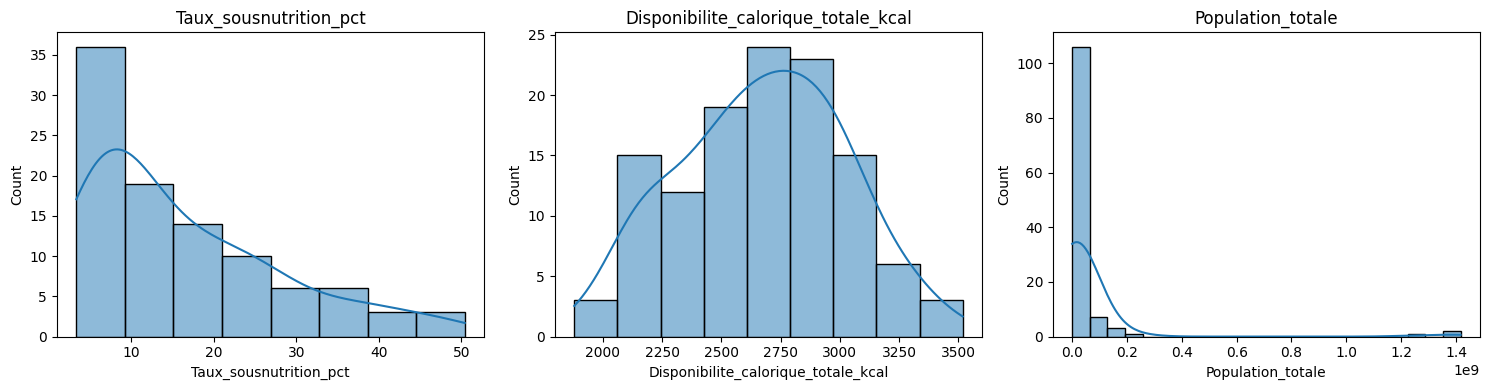

In [26]:
# ============ 1. Analyse univariée ============
variables_cles = ['Taux_sousnutrition_pct', 'Disponibilite_calorique_totale_kcal', 'Population_totale']

print("=== Statistiques descriptives ===")
print(df_global[variables_cles].describe())

print("\n=== Skewness (asymétrie) ===")
for var in variables_cles:
    print(f"{var} : {skew(df_global[var].dropna()):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables_cles):
    sns.histplot(df_global[var], kde=True, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()

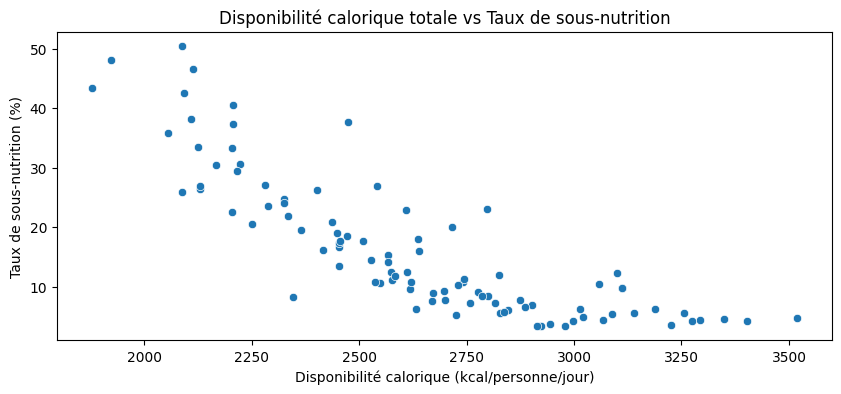

In [27]:
# ============ 2. Analyse bivariée ============
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_global, x='Disponibilite_calorique_totale_kcal', y='Taux_sousnutrition_pct')
plt.title('Disponibilité calorique totale vs Taux de sous-nutrition')
plt.xlabel('Disponibilité calorique (kcal/personne/jour)')
plt.ylabel('Taux de sous-nutrition (%)')
plt.show()

In [28]:
# ============ 3. Top/Bottom rankings ============
print("\n=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===")
print(df_global.nlargest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))

print("\n=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===")
print(df_global.nsmallest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))

print("\n=== Top 10 - Disponibilité calorique la PLUS FAIBLE ===")
print(df_global.nsmallest(10, 'Disponibilite_calorique_totale_kcal')[['Zone', 'Disponibilite_calorique_totale_kcal']].to_string(index=False))



=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===
                                      Zone  Taux_sousnutrition_pct
                                     Haïti               50.402249
                                    Zambie               48.146365
                                  Zimbabwe               46.643110
                 République centrafricaine               43.327556
République populaire démocratique de Corée               42.578831
                                     Congo               40.467626
                                     Tchad               38.206628
                                    Angola               37.723547
                                   Libéria               37.261295
                                Madagascar               35.768811

=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===
                     Zone  Taux_sousnutrition_pct
                  Arménie                3.359086
                 Malaisie                3.365077
  

In [32]:
# ============ 4. Table pivot : groupes de sous-nutrition ============
df_global['Groupe_sousnutrition'] = pd.qcut(
    df_global['Taux_sousnutrition_pct'], q=3, labels=['Faible', 'Moyen', 'Élevé']
)

pivot_groupe = df_global.pivot_table(
    index='Groupe_sousnutrition',
    values=['Kcal_vegetaux', 'Kcal_animaux', 'Disponibilite_calorique_totale_kcal'],
    aggfunc='mean',
    observed=True
)
print("\n=== Pivot : moyenne calorique par groupe de sous-nutrition ===")
print(pivot_groupe)


=== Pivot : moyenne calorique par groupe de sous-nutrition ===
                      Disponibilite_calorique_totale_kcal  Kcal_animaux  \
Groupe_sousnutrition                                                      
Faible                                        2975.125000    531.718750   
Moyen                                         2662.312500    354.593750   
Élevé                                         2265.393939    204.727273   

                      Kcal_vegetaux  
Groupe_sousnutrition                 
Faible                  2443.406250  
Moyen                   2307.718750  
Élevé                   2060.666667  


In [33]:
pivot_groupe['Part_animaux_pct'] = (pivot_groupe['Kcal_animaux'] / pivot_groupe['Disponibilite_calorique_totale_kcal']) * 100
print("\n=== Part des calories animales par groupe ===")
print(pivot_groupe[['Part_animaux_pct']])


=== Part des calories animales par groupe ===
                      Part_animaux_pct
Groupe_sousnutrition                  
Faible                       17.872148
Moyen                        13.319013
Élevé                         9.037160
